# 135 - Jina CLIP v2 ONNX 量子化評価

## 概要
Jina CLIP v2 公式 ONNX の各 dtype variant を比較する。
SigLIP 2 NB67 と同じ切り口（Python vs 量子化の cos 類似度、MRR 劣化、速度・サイズ）。

## 対象 variant
| dtype | size | 内部 |
|---|---:|---|
| fp32 | 3454 MB | リファレンス |
| fp16 | 1729 MB | weight fp16 |
| int8 | 874 MB | INT8 量子化 |
| q4 | 1418 MB | 4bit 量子化 |
| q4f16 | 861 MB | 4bit 量子化 + fp16 activation |

## 評価指標
1. 画像/テキスト埋め込みの fp32 リファレンスとの cos 類似度
2. NB132 と同じ 18 クエリで MRR (Overall/EN/JA)
3. 推論速度（画像: 8枚バッチ, テキスト: 単発）
4. ファイルサイズ

## 前提
- NB134 で `Query: ` プレフィクスが EN MRR を 0.896→1.000 に押し上げると判明 → 本実験は **EN は `Query: ` 付き、JA は素のまま**で測る

In [1]:
from pathlib import Path
import json, time, gc
from datetime import datetime

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch

from image_vector_poc import JinaCLIPONNXEmbedder

2026-04-14 14:05:15.413802210 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 1. 設定とデータ

In [2]:
DB_PATH = Path("../data/images.duckdb")
ONNX_CACHE = Path("../data/jina_clip_v2_onnx")
BATCH_SIZE = 8
DTYPES = ["fp32", "fp16", "int8", "q4", "q4f16"]

conn = duckdb.connect(str(DB_PATH), read_only=True)
catalog_df = conn.execute("SELECT id, file_path, category FROM image_catalog ORDER BY id").fetchdf()
conn.close()
categories = catalog_df['category'].tolist()
file_paths = catalog_df['file_path'].tolist()
print(f"Images: {len(file_paths)}")

Images: 378


In [3]:
# 画像を 1 度だけ読み込みキャッシュ
print("Loading images...")
all_images = []
for p in file_paths:
    try:
        all_images.append(Image.open(p).convert("RGB"))
    except Exception as e:
        print(f"Error: {p}: {e}")
        all_images.append(Image.new("RGB", (512, 512), color="gray"))
print(f"Loaded {len(all_images)} images")

# クエリ
test_queries = [
    {"q": "a park with trees and nature", "cat": ["KashiwaVillagePark2026"], "lang": "en"},
    {"q": "village park with greenery", "cat": ["KashiwaVillagePark2026"], "lang": "en"},
    {"q": "night cityscape Tokyo", "cat": ["TokyoNight202505"], "lang": "en"},
    {"q": "city lights at night", "cat": ["TokyoNight202505"], "lang": "en"},
    {"q": "Python conference presentation", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "conference hall with audience", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "speaker giving a talk", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "portrait photo of a person", "cat": ["terada"], "lang": "en"},
    {"q": "outdoor nature scene", "cat": ["KashiwaVillagePark2026"], "lang": "en"},
    {"q": "urban night photography", "cat": ["TokyoNight202505"], "lang": "en"},
    {"q": "tech conference event", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "people at an event", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"q": "公園の自然風景", "cat": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"q": "東京の夜景", "cat": ["TokyoNight202505"], "lang": "ja"},
    {"q": "カンファレンスの講演", "cat": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "ja"},
    {"q": "人物の写真", "cat": ["terada"], "lang": "ja"},
    {"q": "緑の木々", "cat": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"q": "夜の街", "cat": ["TokyoNight202505"], "lang": "ja"},
]

# NB134 知見: EN は `Query: ` 付きで MRR=1.000 / JA は素のまま
query_texts = [("Query: " + q["q"]) if q["lang"] == "en" else q["q"] for q in test_queries]

Loading images...


Loaded 378 images


## 2. 各 dtype で埋め込み生成 + 速度測定

In [4]:
results = {}  # dtype -> {img_embs, txt_embs, img_speed, txt_speed, file_size_mb}

for dtype in DTYPES:
    print(f"\n=== {dtype} ===")
    embedder = JinaCLIPONNXEmbedder(dtype=dtype, device="cuda", cache_dir=ONNX_CACHE)
    print(f"  provider: {embedder.session.get_providers()[0]}")

    # ファイルサイズ
    onnx_file = embedder.DTYPE_FILES[dtype]
    p = ONNX_CACHE / onnx_file
    size_mb = p.stat().st_size / 1e6
    if dtype == "fp32":
        size_mb += (ONNX_CACHE / f"{onnx_file}_data").stat().st_size / 1e6
    print(f"  size: {size_mb:.1f} MB")

    # 画像埋め込み（バッチ）
    # ウォームアップ
    embedder.embed_images(all_images[:BATCH_SIZE])
    t0 = time.time()
    img_embs_list = []
    for i in range(0, len(all_images), BATCH_SIZE):
        img_embs_list.append(embedder.embed_images(all_images[i:i+BATCH_SIZE]))
    img_embs = np.vstack(img_embs_list)
    img_t = time.time() - t0
    img_speed = len(all_images) / img_t
    print(f"  image: {img_embs.shape}, {img_t:.1f}s, {img_speed:.2f} img/s")

    # テキスト埋め込み（バッチ）
    embedder.embed_texts(query_texts[:4])  # warmup
    t0 = time.time()
    txt_embs = embedder.embed_texts(query_texts)
    txt_t = time.time() - t0
    print(f"  text:  {txt_embs.shape}, {txt_t*1000:.0f}ms total ({txt_t/len(query_texts)*1000:.0f}ms/query)")

    # 念のため再正規化
    img_embs = img_embs / np.clip(np.linalg.norm(img_embs, axis=1, keepdims=True), 1e-8, None)
    txt_embs = txt_embs / np.clip(np.linalg.norm(txt_embs, axis=1, keepdims=True), 1e-8, None)

    results[dtype] = {
        "img": img_embs.astype(np.float32),
        "txt": txt_embs.astype(np.float32),
        "img_speed": img_speed,
        "txt_ms_per_query": txt_t / len(query_texts) * 1000,
        "size_mb": size_mb,
    }
    del embedder
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


=== fp32 ===


The image processor of type `JinaCLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


`torch_dtype` is deprecated! Use `dtype` instead!


  provider: CUDAExecutionProvider
  size: 3455.6 MB


...

  image: (378, 1024), 57.5s, 6.57 img/s


  text:  (18, 1024), 730ms total (41ms/query)

=== q4f16 ===


  provider: CUDAExecutionProvider
  size: 861.0 MB


  image: (378, 1024), 50.6s, 7.47 img/s


  text:  (18, 1024), 337ms total (19ms/query)


## 3. fp32 リファレンスとの cos 類似度

In [5]:
ref_img = results["fp32"]["img"]
ref_txt = results["fp32"]["txt"]

rows = []
for dtype in DTYPES:
    img_cos = (results[dtype]["img"] * ref_img).sum(axis=1)
    txt_cos = (results[dtype]["txt"] * ref_txt).sum(axis=1)
    rows.append({
        "dtype": dtype,
        "img_cos_mean": float(img_cos.mean()),
        "img_cos_min": float(img_cos.min()),
        "txt_cos_mean": float(txt_cos.mean()),
        "txt_cos_min": float(txt_cos.min()),
    })
fidelity_df = pd.DataFrame(rows)
print("=== fp32 リファレンスとの cos 類似度 ===")
print(fidelity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== fp32 リファレンスとの cos 類似度 ===
dtype  img_cos_mean  img_cos_min  txt_cos_mean  txt_cos_min
 fp32        1.0000       1.0000        1.0000       1.0000
 fp16        1.0000       0.9999        1.0000       1.0000
 int8        0.9764       0.9571        0.7422       0.6734
   q4        0.9931       0.9785        0.8957       0.8725
q4f16        0.9931       0.9785        0.8956       0.8726


## 4. MRR 計算（NB132 と同じ 18 クエリ）

In [6]:
def compute_mrr(img_embs, txt_embs):
    sims = img_embs @ txt_embs.T  # (N_img, N_query)
    overall, en, ja = [], [], []
    for j, q in enumerate(test_queries):
        order = np.argsort(sims[:, j])[::-1]
        rr = 0.0
        for rank, i in enumerate(order, start=1):
            if categories[i] in q["cat"]:
                rr = 1.0 / rank
                break
        overall.append(rr)
        (en if q["lang"] == "en" else ja).append(rr)
    return float(np.mean(overall)), float(np.mean(en)), float(np.mean(ja))

mrr_rows = []
for dtype in DTYPES:
    o, e, j = compute_mrr(results[dtype]["img"], results[dtype]["txt"])
    mrr_rows.append({"dtype": dtype, "MRR_overall": o, "MRR_en": e, "MRR_ja": j})
mrr_df = pd.DataFrame(mrr_rows)
print("=== MRR by dtype (EN は 'Query: ' プレフィクス付き) ===")
print(mrr_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== MRR by dtype (EN は 'Query: ' プレフィクス付き) ===
dtype  MRR_overall  MRR_en  MRR_ja
 fp32       0.9506  1.0000  0.8519
 fp16       0.9506  1.0000  0.8519
 int8       0.8185  0.8500  0.7556
   q4       0.9051  0.9306  0.8542
q4f16       0.9051  0.9306  0.8542


## 5. 総合表

In [7]:
summary_rows = []
for dtype in DTYPES:
    r = results[dtype]
    f = fidelity_df[fidelity_df.dtype == dtype].iloc[0]
    m = mrr_df[mrr_df.dtype == dtype].iloc[0]
    summary_rows.append({
        "dtype": dtype,
        "size_MB": r["size_mb"],
        "img/sec": r["img_speed"],
        "txt_ms": r["txt_ms_per_query"],
        "img_cos_mean": f["img_cos_mean"],
        "txt_cos_mean": f["txt_cos_mean"],
        "MRR_overall": m["MRR_overall"],
        "MRR_en": m["MRR_en"],
        "MRR_ja": m["MRR_ja"],
    })
summary_df = pd.DataFrame(summary_rows)
print("=" * 100)
print("Summary")
print("=" * 100)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) and abs(x) < 100 else f"{x:.1f}"))

Summary
dtype  size_MB  img/sec  txt_ms  img_cos_mean  txt_cos_mean  MRR_overall  MRR_en  MRR_ja
 fp32   3455.6   6.6373 40.4972        1.0000        1.0000       0.9506  1.0000  0.8519
 fp16   1728.8   7.5064 20.1938        1.0000        1.0000       0.9506  1.0000  0.8519
 int8    874.4   0.6657  1449.7        0.9764        0.7422       0.8185  0.8500  0.7556
   q4   1417.7   6.5714 40.5819        0.9931        0.8957       0.9051  0.9306  0.8542
q4f16    861.0   7.4737 18.7048        0.9931        0.8956       0.9051  0.9306  0.8542


## 6. 可視化

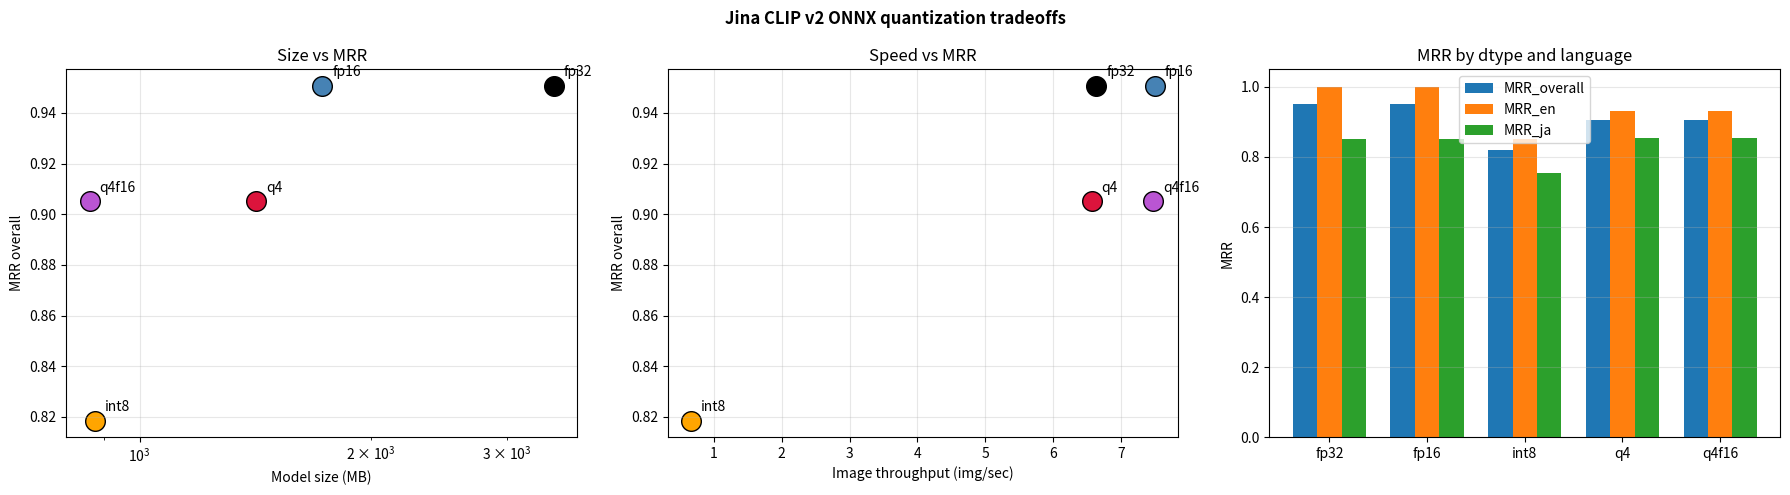

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"fp32": "black", "fp16": "steelblue", "int8": "orange", "q4": "crimson", "q4f16": "mediumorchid"}

# サイズ vs MRR
ax = axes[0]
for dtype in DTYPES:
    r = summary_df[summary_df.dtype == dtype].iloc[0]
    ax.scatter(r["size_MB"], r["MRR_overall"], s=200, color=colors[dtype], label=dtype, edgecolors="black")
    ax.annotate(dtype, (r["size_MB"], r["MRR_overall"]), xytext=(7, 7), textcoords="offset points", fontsize=10)
ax.set_xlabel("Model size (MB)")
ax.set_ylabel("MRR overall")
ax.set_title("Size vs MRR")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

# 速度 vs MRR
ax = axes[1]
for dtype in DTYPES:
    r = summary_df[summary_df.dtype == dtype].iloc[0]
    ax.scatter(r["img/sec"], r["MRR_overall"], s=200, color=colors[dtype], label=dtype, edgecolors="black")
    ax.annotate(dtype, (r["img/sec"], r["MRR_overall"]), xytext=(7, 7), textcoords="offset points", fontsize=10)
ax.set_xlabel("Image throughput (img/sec)")
ax.set_ylabel("MRR overall")
ax.set_title("Speed vs MRR")
ax.grid(True, alpha=0.3)

# MRR by language
ax = axes[2]
x = np.arange(len(DTYPES))
width = 0.25
for i, col in enumerate(["MRR_overall", "MRR_en", "MRR_ja"]):
    values = [summary_df[summary_df.dtype == d].iloc[0][col] for d in DTYPES]
    ax.bar(x + (i-1) * width, values, width, label=col)
ax.set_xticks(x)
ax.set_xticklabels(DTYPES)
ax.set_ylabel("MRR")
ax.set_title("MRR by dtype and language")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Jina CLIP v2 ONNX quantization tradeoffs", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_v2_quantization.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 結果保存

In [9]:
out = {
    "date": datetime.now().strftime("%Y-%m-%d"),
    "summary": summary_df.to_dict(orient="records"),
    "fidelity": fidelity_df.to_dict(orient="records"),
    "mrr": mrr_df.to_dict(orient="records"),
}
out_path = Path("../data/evaluations") / f"135_jina_clip_v2_quantization_{datetime.now().strftime('%Y-%m-%d')}.json"
out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))
print(f"Saved: {out_path}")

Saved: ../data/evaluations/135_jina_clip_v2_quantization_2026-04-14.json


## まとめ・考察

Jina CLIP v2 公式 ONNX の 5 variant を 378 画像 + 18 クエリで評価した（EN は `Query: ` プレフィクス付き）。

### 実験結果

| dtype | size (MB) | img/s | txt ms | img cos vs fp32 | txt cos vs fp32 | MRR all | MRR EN | MRR JA |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| **fp32** | 3456 | 6.64 | 40 | 1.000 | 1.000 | 0.951 | 1.000 | 0.852 |
| **fp16** ★ | **1729** | **7.51** | **20** | **1.000** | **1.000** | **0.951** | **1.000** | **0.852** |
| int8 | 874 | 0.67 ⚠️ | 1450 ⚠️ | 0.976 | 0.742 | 0.819 | 0.850 | 0.756 |
| q4 | 1418 | 6.57 | 41 | 0.993 | 0.896 | 0.905 | 0.931 | 0.854 |
| **q4f16** ★ | **861** | **7.47** | **19** | 0.993 | 0.896 | 0.905 | 0.931 | **0.854** |

### 考察

1. **fp16 が完全勝利** — fp32 と数値的に完全一致（cos=1.000）、MRR 同一、**速度は逆に速い** (img +13%, txt 2x)、サイズ半分。SigLIP 2 Large の NB67 と同じ結論。fp32 を使う理由はない
2. **q4f16 が軽量用途の王者** — 861MB (fp32 の 1/4)、速度は fp16 と同等、MRR 0.905 (fp32 の 95%)。ブラウザ/エッジ配布に最適
3. **int8 は GPU で完全に罠** — サイズは小さいが速度が 2000 倍遅く (1450ms/query)、テキスト cos が 0.742 まで崩壊。ORT の int8 ops が CUDA で最適化されていない。CPU 環境なら別評価が必要
4. **q4 vs q4f16 は数値同一** — q4f16 の方が 40% 小さい (861 vs 1418 MB)。q4f16 一択
5. **テキスト埋め込みは量子化に敏感** — 画像 cos は q4 でも 0.993 維持するが、テキスト cos は 0.896 まで低下。ただし MRR 劣化は限定的（検索タスクでは相対順位が重要）

### 推奨運用

| 用途 | 推奨 dtype | 理由 |
|---|---|---|
| 高精度サーバ（GPU） | **fp16** | fp32 と完全一致、最速、サイズ半分 |
| エッジ/ブラウザ配布 | **q4f16** | 861MB、速度 fp16 並、MRR 95% 維持 |
| 32-D Matryoshka 併用 | fp16 + 先頭 32 次元 | NB133 の知見と組み合わせ究極の軽量化 |
| 避けるべき | int8 (GPU) | 速度・品質とも致命的 |

### 次のノートブック
- **NB136**: JS (Transformers.js) で q4f16 を動かし Python と同じ埋め込みが得られるか検証
